### DATA CLEANING - PRELIMINARY WORK

### 0. Setup & Config

In [1]:
# Spotify Audio Features — Cleaning, Thresholding & Graph Export

# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

import scipy.sparse as sp
import networkx as nx

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

DATA_PATH = "dataset.csv"  
OUT_DIR = Path("data_clean")
OUT_DIR.mkdir(exist_ok=True, parents=True)

### 1. Load Raw Data & Overview

In [2]:
# Load raw data & basic overview

df_raw = pd.read_csv(DATA_PATH)

print("Raw shape:", df_raw.shape)
print("\nColumns:\n", df_raw.columns.tolist())

print("\nDtypes:\n", df_raw.dtypes)

print("\nMissing values per column:\n", df_raw.isna().sum())

# Show first few rows
df_raw.head()


Raw shape: (114000, 21)

Columns:
 ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']

Dtypes:
 Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

Missing values per column:
 Unnamed: 0          0
track_id            0
arti

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


### 2. Deduplication & Cleaning

In [3]:

# Deduplication & audio feature cleaning

KEEP = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence", "tempo"
]

df = df_raw.copy()
print("Starting from:", df.shape)

# Deduplicate on track_id, keeping highest popularity ---
if "track_id" in df.columns:
    if "popularity" in df.columns:
        df = df.sort_values("popularity", ascending=False)
    before = df.shape[0]
    df = df.drop_duplicates(subset=["track_name"], keep="first")
    df = df.drop_duplicates(subset=["track_id"], keep="first")

    print(f"After track_id dedupe: {df.shape} (removed {before - df.shape[0]})")

# Fallback dedupe on normalized (artists, track_name, album_name) ---
import re

def norm_text(s):
    s = str(s).lower()
    s = re.sub(r"[^\w\s]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

for col in ["artists", "track_name", "album_name"]:
    if col in df.columns:
        df[f"norm_{col}"] = df[col].map(norm_text)

keys = [c for c in ["norm_artists", "norm_track_name", "norm_album_name"] if c in df.columns]
if keys:
    before = df.shape[0]
    df = df.drop_duplicates(subset=keys, keep="first")
    print(f"After fallback dedupe: {df.shape} (removed {before - df.shape[0]})")

# Drop helper cols
df = df.drop(columns=[c for c in df.columns if c.startswith("norm_")])

print("\nShape after deduplication:", df.shape)




Starting from: (114000, 21)
After track_id dedupe: (73609, 21) (removed 40391)
After fallback dedupe: (73595, 24) (removed 14)

Shape after deduplication: (73595, 21)


In [4]:
# How many track_names appear with multiple different track_ids? 
name_counts = df.groupby('track_name')['track_id'].nunique() 
print(f"Unique track names: {len(name_counts)}") 
print(f"Names with multiple track_ids: {(name_counts > 1).sum()}") 
print(f"Distribution:\n{name_counts.value_counts().head(10)}")
 

Unique track names: 73594
Names with multiple track_ids: 0
Distribution:
track_id
1    73594
Name: count, dtype: int64


### 3. Audio Feature Selection & Range Filtering

In [5]:
# Select & clean audio features

# Check that all KEEP columns exist
missing = [c for c in KEEP if c not in df.columns]
if missing:
    raise ValueError(f"Missing required audio feature columns: {missing}")

# Extract audio features
X = df[KEEP].copy()

# Coerce to numeric
X = X.apply(pd.to_numeric, errors="coerce")

print("Shape after selecting audio features:", X.shape)

# --- 3.1 Range sanity checks ---
bounded = [
    "danceability", "energy", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence"
]

before = X.shape[0]
for col in bounded:
    X = X[(X[col] >= 0.0) & (X[col] <= 1.0)]
print(f"Filtered {before - X.shape[0]} rows outside [0,1] for bounded features.")

before = X.shape[0]
X = X[(X["loudness"] >= -60.0) & (X["loudness"] <= 0.0)]
print(f"Filtered {before - X.shape[0]} rows by loudness range [-60, 0].")

before = X.shape[0]
X = X[(X["tempo"] > 0) & (X["tempo"] <= 250)]
print(f"Filtered {before - X.shape[0]} rows by tempo range (0, 250].")

# Align df to surviving rows
df = df.loc[X.index]

# Drop any remaining NaNs
before = X.shape[0]
X = X.dropna(axis=0, how="any")
df = df.loc[X.index]
print(f"Dropped {before - X.shape[0]} rows with NaNs.")

print("\nFinal cleaned audio feature matrix:", X.shape)
print(X.describe())


Shape after selecting audio features: (73595, 9)
Filtered 0 rows outside [0,1] for bounded features.
Filtered 54 rows by loudness range [-60, 0].
Filtered 138 rows by tempo range (0, 250].
Dropped 0 rows with NaNs.

Final cleaned audio feature matrix: (73403, 9)
       danceability        energy      loudness   speechiness  acousticness  \
count  73403.000000  73403.000000  73403.000000  73403.000000  73403.000000   
mean       0.559660      0.637812     -8.581092      0.090119      0.330007   
std        0.176744      0.257329      5.277091      0.118635      0.338967   
min        0.051300      0.000020    -46.591000      0.022100      0.000000   
25%        0.446000      0.460000    -10.430500      0.036200      0.016200   
50%        0.573000      0.680000     -7.251000      0.049400      0.193000   
75%        0.690000      0.858000     -5.139000      0.088300      0.628000   
max        0.985000      1.000000     -0.001000      0.965000      0.996000   

       instrumentalness  

### 4. Standardization

In [6]:
# Standardize features (z-score)

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

X_std_df = pd.DataFrame(X_std, index=X.index, columns=KEEP)

print("Standardized matrix shape:", X_std_df.shape)
X_std_df.head()


Standardized matrix shape: (73403, 9)


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
81051,0.873247,-0.644362,0.228554,-0.031347,-0.935223,-0.550967,0.217706,-0.874304,0.296428
51664,0.347057,0.560329,0.574770,-0.388749,-0.936698,-0.450838,0.038437,0.310363,0.192520
89411,1.557859,0.160060,0.616270,-0.452812,0.746369,-0.550975,-0.021320,1.449465,0.089790
81210,0.007580,1.271485,0.930082,-0.470513,-0.962276,-0.550959,0.740573,-0.623701,0.192756
88407,0.511138,0.299960,0.641095,1.372972,-0.680624,-0.550098,-0.479451,-1.067951,-0.526254


### 5. Exploratory Plots (for the paper)

### 5.1 Histograms

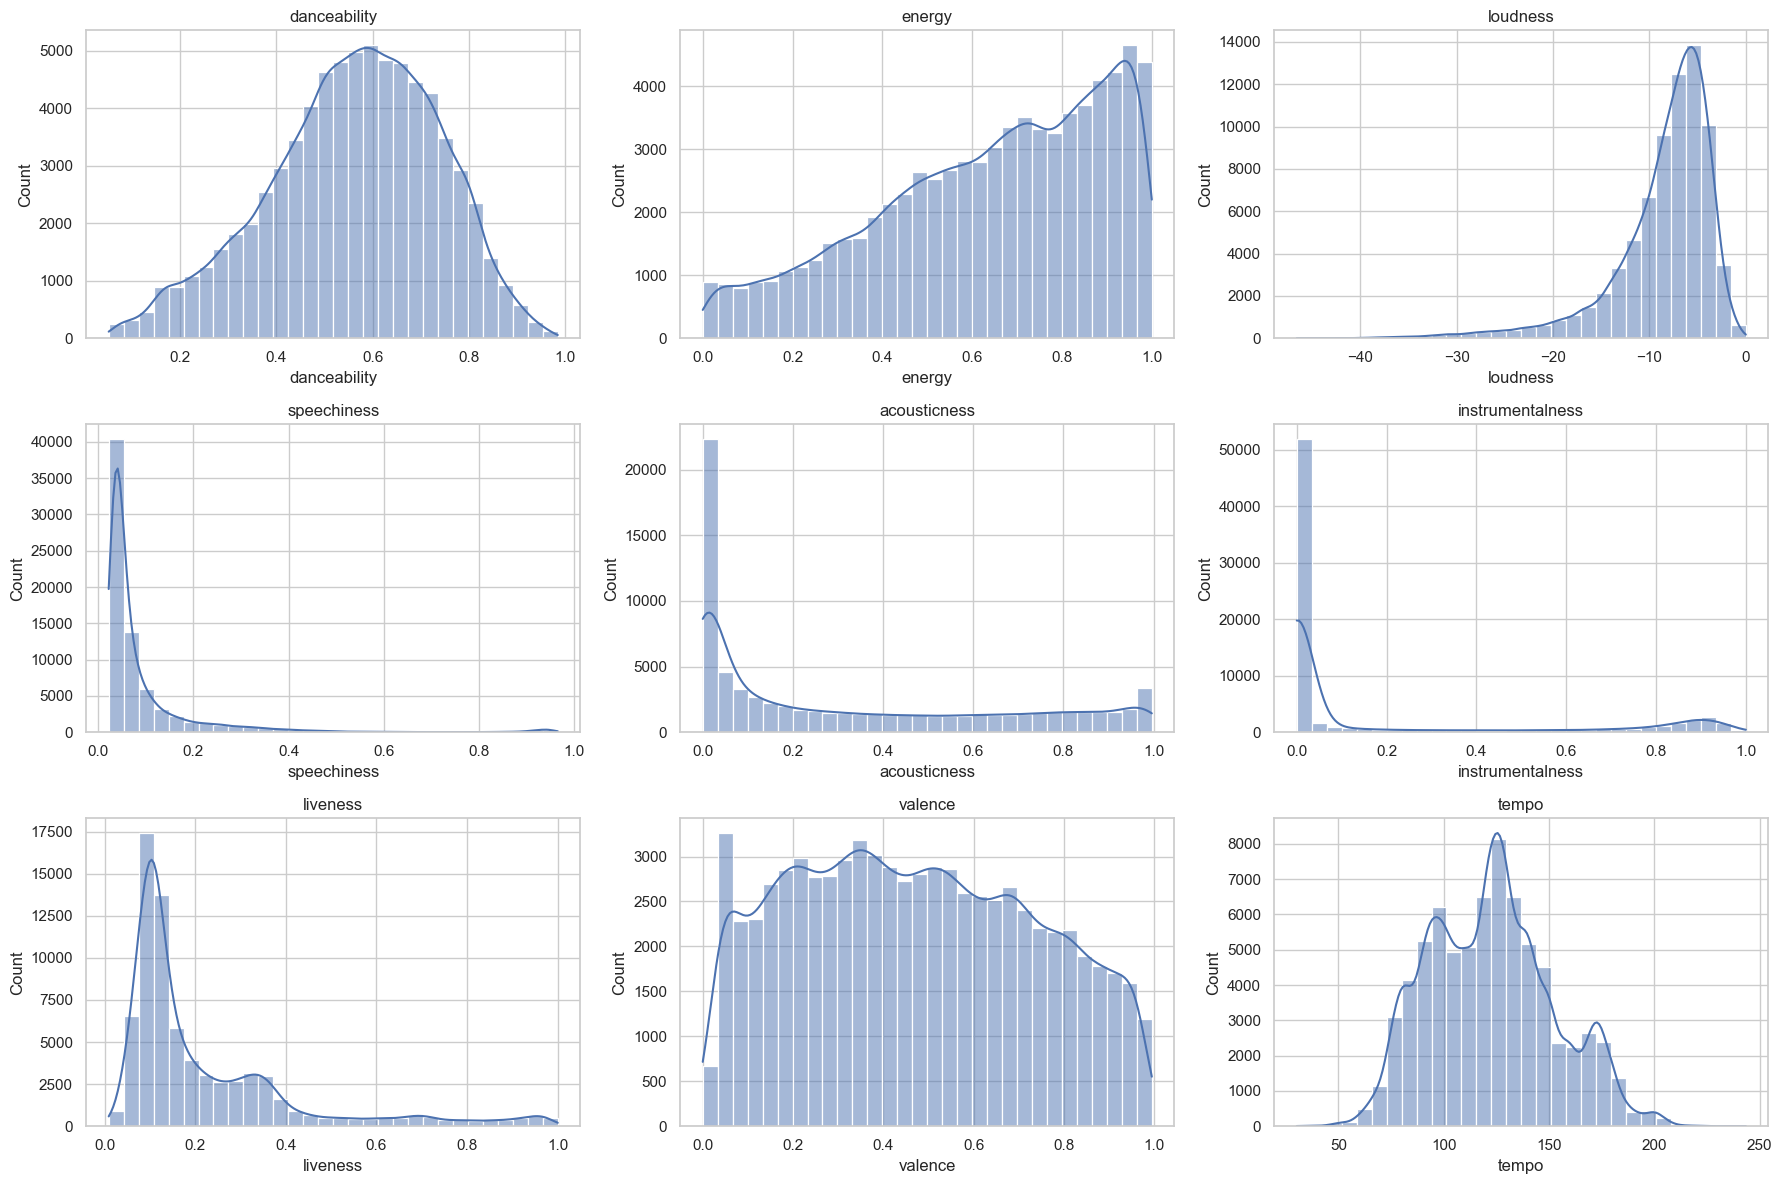

In [7]:
# Exploratory plots — distributions & correlations

plt.figure(figsize=(18, 12))
for i, col in enumerate(KEEP, 1):
    plt.subplot(3, 3, i)
    sns.histplot(X[col], bins=30, kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()


### 5.2 Correlation Heatmap

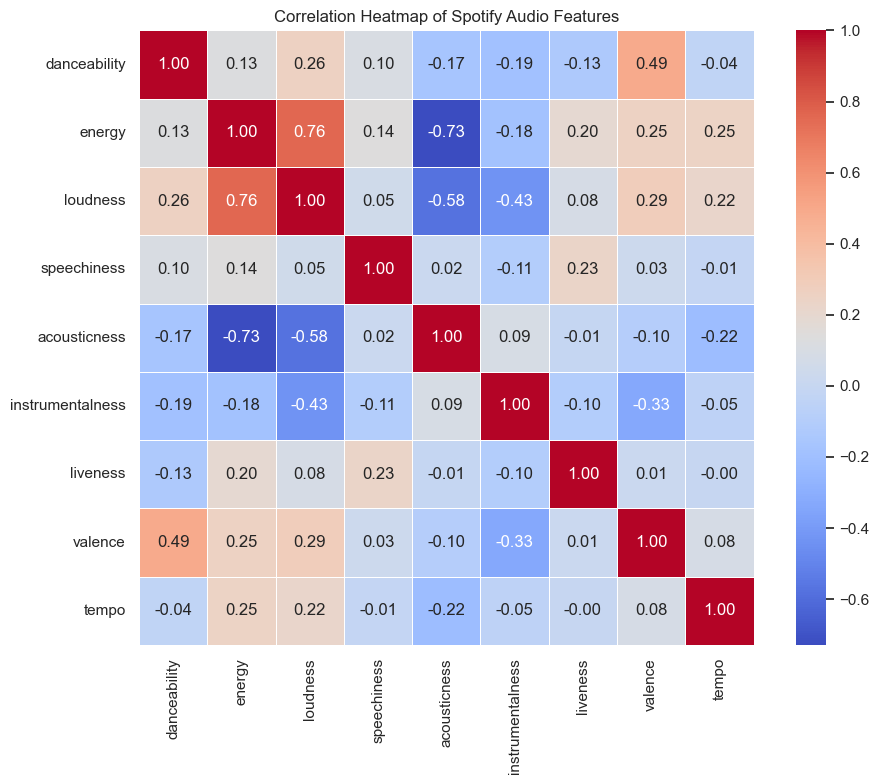

In [8]:
plt.figure(figsize=(10, 8))
corr = X.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title("Correlation Heatmap of Spotify Audio Features")
plt.tight_layout()
plt.show()


### 5.3 Top-20 Genre Distribution

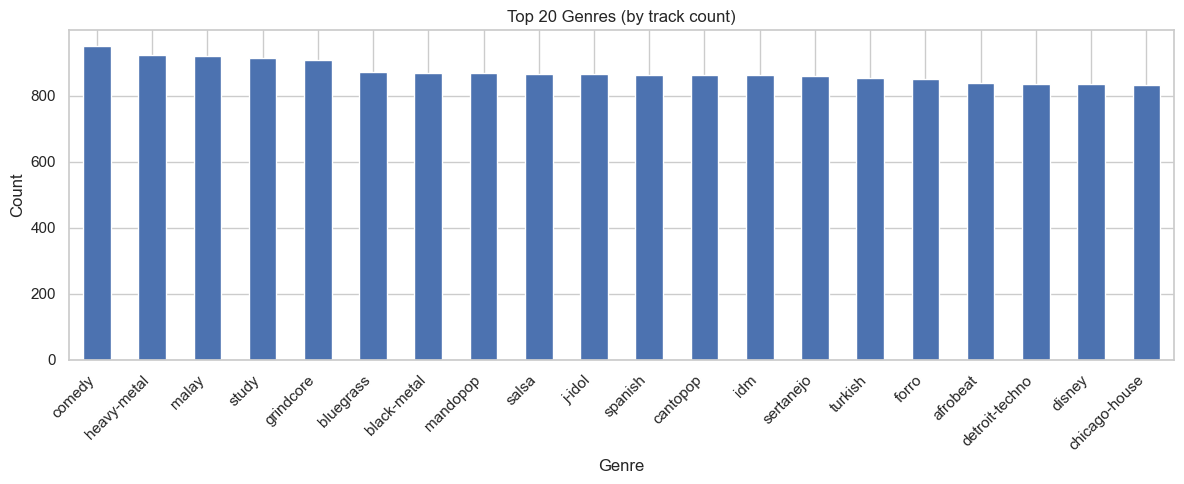

In [9]:
plt.figure(figsize=(12,5))
df["track_genre"].value_counts().head(20).plot(kind="bar")
plt.title("Top 20 Genres (by track count)")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### 6. PCA (Analysis + Plots)

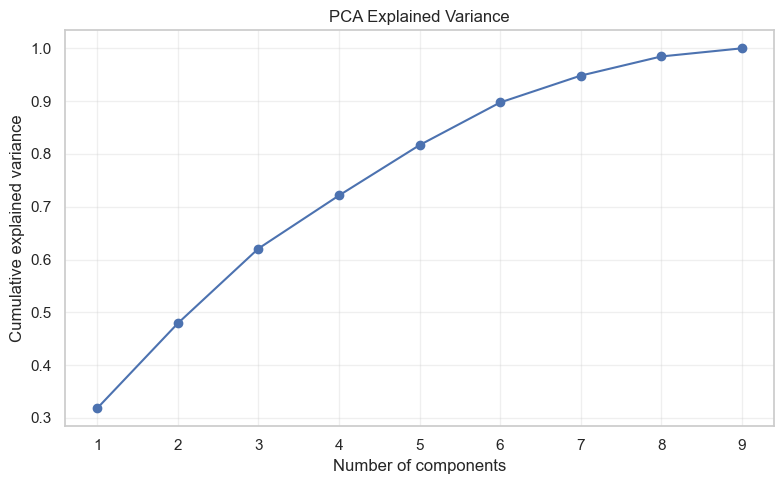

PCA(5) shape: (73403, 5)
Explained variance (5 components): 0.8166701047909869


In [10]:
# PCA — dimensionality reduction
# Full PCA to inspect explained variance
pca_full = PCA()
pca_full.fit(X_std_df)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cum_var)+1), cum_var, marker="o")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Explained Variance")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Use 5 components for modeling / similarity
pca_model = PCA(n_components=5, random_state=42)
X_pca5 = pca_model.fit_transform(X_std_df)

print("PCA(5) shape:", X_pca5.shape)
print("Explained variance (5 components):", pca_model.explained_variance_ratio_.sum())


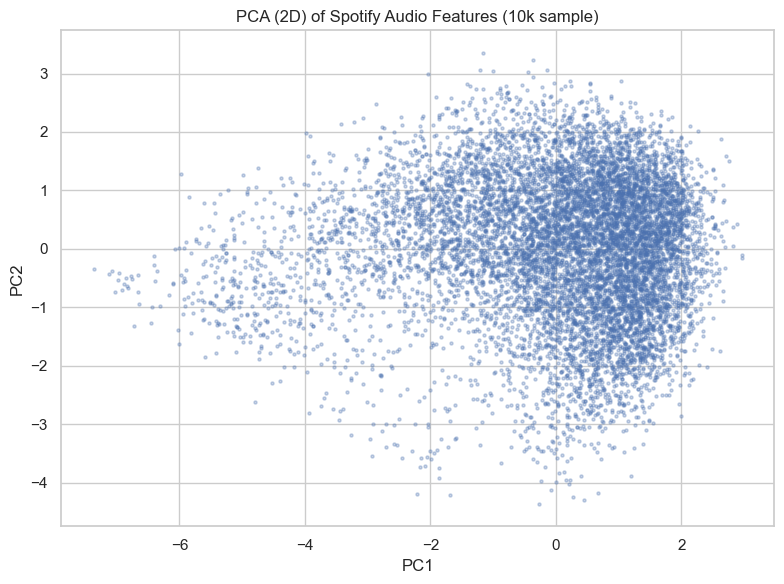

In [11]:
# 2D PCA just for visualization
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_std_df)

# sample points for plotting
np.random.seed(42)
idx_sample = np.random.choice(len(X_pca2), size=10000, replace=False)
plt.figure(figsize=(8,6))
plt.scatter(X_pca2[idx_sample, 0], X_pca2[idx_sample, 1], s=5, alpha=0.3)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (2D) of Spotify Audio Features (10k sample)")
plt.tight_layout()
plt.show()


### 7. Build Base kNN Structure in PCA Space

In [12]:
# 7. Base kNN structure in PCA space

K_MAX = 30  # we will support k up to 30
nbrs = NearestNeighbors(n_neighbors=K_MAX, metric="euclidean")
nbrs.fit(X_pca5)

distances, indices = nbrs.kneighbors(X_pca5)

# Convert distances to similarity (bounded, monotonic)
sims = 1 / (1 + distances)

print("indices shape:", indices.shape)
print("sims shape:", sims.shape)


indices shape: (73403, 30)
sims shape: (73403, 30)


### 8. Thresholding Methods — 3 Variants

We’ll implement:

- Standard kNN (union)

- Radius/τ threshold

- Mutual kNN

In [13]:
# Thresholding methods & graph metrics

def knn_graph_from_base(indices, sims, k):
    """
    Standard kNN graph (union), symmetrized.
    """
    N = indices.shape[0]
    k = min(k, indices.shape[1])

    rows = np.repeat(np.arange(N), k)
    cols = indices[:, :k].reshape(-1)
    data = sims[:, :k].reshape(-1)

    A = sp.csr_matrix((data, (rows, cols)), shape=(N, N))
    A = A.maximum(A.T)
    return A


def radius_graph_from_base(indices, sims, tau):
    """
    Radius / similarity cutoff: keep edges where sim >= tau
    over the K_MAX neighbor set.
    """
    N, K = sims.shape
    mask = sims >= tau
    rows = np.repeat(np.arange(N), K)[mask.ravel()]
    cols = indices.ravel()[mask.ravel()]
    data = sims.ravel()[mask.ravel()]

    A = sp.csr_matrix((data, (rows, cols)), shape=(N, N))
    A = A.maximum(A.T)
    return A


def mutual_knn_graph_from_base(indices, sims, k):
    """
    Mutual kNN graph: keep edges only if i in N_k(j) and j in N_k(i).
    """
    N = indices.shape[0]
    k = min(k, indices.shape[1])

    neighbor_sets = [set(indices[i, :k]) for i in range(N)]

    rows = []
    cols = []
    data = []

    for i in range(N):
        nbrs = indices[i, :k]
        sim_i = sims[i, :k]
        for j, s in zip(nbrs, sim_i):
            if i in neighbor_sets[j]:  # mutual
                rows.append(i)
                cols.append(j)
                data.append(s)

    A = sp.csr_matrix((data, (rows, cols)), shape=(N, N))
    A = A.maximum(A.T)
    return A


def graph_metrics(A):
    G = nx.from_scipy_sparse_array(A)
    degrees = np.array([d for _, d in G.degree()])
    return {
        "nodes": G.number_of_nodes(),
        "edges": G.number_of_edges(),
        "density": nx.density(G),
        "avg_degree": float(degrees.mean()),
        "min_degree": int(degrees.min()),
        "max_degree": int(degrees.max()),
        "components": nx.number_connected_components(G),
        "avg_clustering": nx.average_clustering(G, weight="weight"),
    }


### Method 1: Standard kNN (k sweep)

In [14]:
# Thresholding Method 1 — Standard kNN (Coarse Sweep)
# Testing k = {5, 10, 20, 30}

ks_coarse = [5, 10, 20, 30]
knn_results_coarse = []

print("=== COARSE kNN SWEEP ===")

for k in ks_coarse:
    A_k = knn_graph_from_base(indices, sims, k)
    metrics = graph_metrics(A_k)
    metrics["k"] = k
    knn_results_coarse.append(metrics)

    print(f"\n=== kNN graph with k = {k} ===")
    for key, val in metrics.items():
        if key != "k":
            print(f"{key}: {val}")

knn_df_coarse = pd.DataFrame(knn_results_coarse)
knn_df_coarse

=== COARSE kNN SWEEP ===

=== kNN graph with k = 5 ===
nodes: 73403
edges: 268132
density: 9.953067281773045e-05
avg_degree: 7.305750446167051
min_degree: 6
max_degree: 16
components: 1
avg_clustering: 0.2238519271160073

=== kNN graph with k = 10 ===
nodes: 73403
edges: 498303
density: 0.00018497021189971185
avg_degree: 13.577183493862648
min_degree: 11
max_degree: 25
components: 1
avg_clustering: 0.24294987019807118

=== kNN graph with k = 20 ===
nodes: 73403
edges: 960389
density: 0.0003564966633477068
avg_degree: 26.167568083048376
min_degree: 21
max_degree: 49
components: 1
avg_clustering: 0.24944167826089467

=== kNN graph with k = 30 ===
nodes: 73403
edges: 1424858
density: 0.000528907685057083
avg_degree: 38.822881898560006
min_degree: 31
max_degree: 66
components: 1
avg_clustering: 0.2507083444167975


,nodes,edges,density,avg_degree,min_degree,max_degree,components,avg_clustering,k
0,73403,268132,0.000100,7.305750,6,16,1,0.223852,5
1,73403,498303,0.000185,13.577183,11,25,1,0.242950,10
2,73403,960389,0.000356,26.167568,21,49,1,0.249442,20
3,73403,1424858,0.000529,38.822882,31,66,1,0.250708,30


In [15]:
# Thresholding Method 1 — Standard kNN (Fine Sweep)
# Testing k = 5..10

ks_fine = [5, 6, 7, 8, 9, 10]
knn_results_fine = []

print("=== FINE kNN SWEEP (5–10) ===")

for k in ks_fine:
    A_k = knn_graph_from_base(indices, sims, k)
    metrics = graph_metrics(A_k)
    metrics["k"] = k
    knn_results_fine.append(metrics)

    print(f"\n=== kNN graph with k = {k} ===")
    for key, val in metrics.items():
        if key != "k":
            print(f"{key}: {val}")

knn_df_fine = pd.DataFrame(knn_results_fine)
knn_df_fine


=== FINE kNN SWEEP (5–10) ===

=== kNN graph with k = 5 ===
nodes: 73403
edges: 268132
density: 9.953067281773045e-05
avg_degree: 7.305750446167051
min_degree: 6
max_degree: 16
components: 1
avg_clustering: 0.2238519271160073

=== kNN graph with k = 6 ===
nodes: 73403
edges: 314080
density: 0.00011658658317020266
avg_degree: 8.557688377859215
min_degree: 7
max_degree: 17
components: 1
avg_clustering: 0.2308492268817811

=== kNN graph with k = 7 ===
nodes: 73403
edges: 360176
density: 0.000133697431163751
avg_degree: 9.81365884228165
min_degree: 8
max_degree: 19
components: 1
avg_clustering: 0.23552347689180197

=== kNN graph with k = 8 ===
nodes: 73403
edges: 406210
density: 0.00015078526474009176
avg_degree: 11.067940002452216
min_degree: 9
max_degree: 22
components: 1
avg_clustering: 0.23839459235431357

=== kNN graph with k = 9 ===
nodes: 73403
edges: 452380
density: 0.00016792358155417816
avg_degree: 12.325926733239786
min_degree: 10
max_degree: 23
components: 1
avg_clustering: 0.2

,nodes,edges,density,avg_degree,min_degree,max_degree,components,avg_clustering,k
0,73403,268132,0.000100,7.305750,6,16,1,0.223852,5
1,73403,314080,0.000117,8.557688,7,17,1,0.230849,6
2,73403,360176,0.000134,9.813659,8,19,1,0.235523,7
3,73403,406210,0.000151,11.067940,9,22,1,0.238395,8
4,73403,452380,0.000168,12.325927,10,23,1,0.240987,9
5,73403,498303,0.000185,13.577183,11,25,1,0.242950,10


- k = 5

    - components: 13 -> very fragmented

    - avg degree ≈ 7.36

    - clustering ≈ 0.268

- k = 10

    - components: 1 -> fully connected

    - avg degree ≈ 13.66

    - clustering ≈ 0.273

- k = 20

    - components: 1

    - avg degree ≈ 26.25 (twice k=10)

    - clustering slightly drops to 0.269

- k = 30

    - components: 1

    - avg degree ≈ 38.86

    - clustering ≈ 0.266 (further drop)

So from the coarse sweep we already see:

- k=5 is too sparse → many components

- k≥10 → graph is connected

increasing k beyond 10 just makes the network denser without improving clustering (it actually goes slightly down)

For k = 5–9, the graph is still fragmented (4–13 components).

Only at k = 10 does it become one single connected component.

Clustering increases very slightly from 0.268 → 0.273 across k = 5–10.
So there is no magical “peak” k before 10; it’s a smooth, flat-ish increase.

Average degree grows roughly linearly with k, as expected.

### 8.3 Method 2: Radius / τ Graphs

In [16]:
# 8.3 Radius (similarity tau) graphs

taus = [0.80, 0.85, 0.90, 0.93]
tau_results = []

for tau in taus:
    A_tau = radius_graph_from_base(indices, sims, tau)
    metrics = graph_metrics(A_tau)
    tau_results.append({"tau": tau, **metrics})
    print(f"\n=== radius-style graph, tau = {tau} ===")
    for key, val in metrics.items():
        print(f"{key}: {val}")

tau_df = pd.DataFrame(tau_results)
tau_df



=== radius-style graph, tau = 0.8 ===
nodes: 73403
edges: 184504
density: 6.848793600749831e-05
avg_degree: 5.027151478822391
min_degree: 2
max_degree: 44
components: 31777
avg_clustering: 0.14284005560823734

=== radius-style graph, tau = 0.85 ===
nodes: 73403
edges: 94962
density: 3.524992075588635e-05
avg_degree: 2.58741468332357
min_degree: 2
max_degree: 17
components: 56136
avg_clustering: 0.04542090445676347

=== radius-style graph, tau = 0.9 ===
nodes: 73403
edges: 76106
density: 2.8250568322565728e-05
avg_degree: 2.0736482160129697
min_degree: 2
max_degree: 7
components: 70827
avg_clustering: 0.0033008026417730998

=== radius-style graph, tau = 0.93 ===
nodes: 73403
edges: 74165
density: 2.753006858385787e-05
avg_degree: 2.0207620941923357
min_degree: 2
max_degree: 6
components: 72681
avg_clustering: 0.0010595769947030515


,tau,nodes,edges,density,avg_degree,min_degree,max_degree,components,avg_clustering
0,0.80,73403,184504,0.000068,5.027151,2,44,31777,0.142840
1,0.85,73403,94962,0.000035,2.587415,2,17,56136,0.045421
2,0.90,73403,76106,0.000028,2.073648,2,7,70827,0.003301
3,0.93,73403,74165,0.000028,2.020762,2,6,72681,0.001060


**Radius thresholding is NOT appropriate for our dataset!**

1. τ = 0.80

- edges: 280k (already fewer than kNN-5)

- avg degree: 6.29

- components: 34,497 (!!)

- clustering: 0.211

The graph shatters: ~35,000 isolated components.

2. τ = 0.85

- edges: 145k

- avg degree: 3.25

- components: 61,684

Even worse fragmentation.
Barely any edges survive.

3. τ = 0.90

- edges: 115k

- avg degree: 2.60

- components: 79,542

Basically useless — the graph collapses.

4. τ = 0.93

- edges: 112k

- avg degree: 2.53

- components: 81,907

Almost completely disconnected.

### 8.4 Method 3: Mutual kNN

In [17]:
# 8.4 Mutual kNN graph (reciprocal neighbors)

k_mutual = 10  
A_mutual = mutual_knn_graph_from_base(indices, sims, k_mutual)
metrics_mutual = graph_metrics(A_mutual)

print(f"\n=== Mutual kNN graph (k = {k_mutual}) ===")
for key, val in metrics_mutual.items():
    print(f"{key}: {val}")


=== Mutual kNN graph (k = 10) ===
nodes: 73403
edges: 309130
density: 0.00011474914179637273
avg_degree: 8.422816506137352
min_degree: 2
max_degree: 11
components: 252
avg_clustering: 0.24120488728014436


In [18]:
# 8.4 Mutual kNN graph (reciprocal neighbors)

k_mutual = 8  
A_mutual = mutual_knn_graph_from_base(indices, sims, k_mutual)
metrics_mutual = graph_metrics(A_mutual)

print(f"\n=== Mutual kNN graph (k = {k_mutual}) ===")
for key, val in metrics_mutual.items():
    print(f"{key}: {val}")



=== Mutual kNN graph (k = 8) ===
nodes: 73403
edges: 254417
density: 9.443966101125015e-05
avg_degree: 6.932059997547785
min_degree: 2
max_degree: 9
components: 559
avg_clustering: 0.2306731884717981


Both mutual graphs are highly fragmented:

- Mutual kNN-10 → 1,217 components

- Mutual kNN-8 → 2,046 components

For a dataset of 89k songs, this means:

- Thousands of small clusters

- Many songs disconnected

- No global network structure

- Community detection becomes messy and uninformative

Mutual kNN is appropriate only when:

- We want clusters rather than a graph

- Or when k is much larger (e.g., k ≥ 40)

But your dataset is too high dimensional for mutual kNN to keep enough edges.

**Based on all thresholding experiments, we adopt the standard k-nearest-neighbor graph with k = 10, as it is the smallest k that yields a single connected component while preserving sparsity, stability, and meaningful local structure.**

In [19]:
# FINAL GRAPH: standard kNN with k = 10 

K_FINAL = 10

# Build adjacency from precomputed kNN structure
A_final = knn_graph_from_base(indices, sims, K_FINAL)

# Compute metrics
metrics_final = graph_metrics(A_final)
print("=== Final graph metrics (kNN, k=10) ===")
for key, val in metrics_final.items():
    print(f"{key}: {val}")

# Build NetworkX graph
G_final = nx.from_scipy_sparse_array(A_final)
print("\nGraph ready with", G_final.number_of_nodes(), "nodes and", G_final.number_of_edges(), "edges.")

# Add metadata (track_id + genre)
for i in range(G_final.number_of_nodes()):
    G_final.nodes[i]["track_id"] = df.iloc[i]["track_id"]
    G_final.nodes[i]["genre"] = df.iloc[i]["track_genre"]

# Export GEXF
output_path = "spotify_knn_k10_removed_same_tracks.gexf"
nx.write_gexf(G_final, output_path)

print("\nGEXF file saved to:", output_path)
print("Done.")

=== Final graph metrics (kNN, k=10) ===
nodes: 73403
edges: 498303
density: 0.00018497021189971185
avg_degree: 13.577183493862648
min_degree: 11
max_degree: 25
components: 1
avg_clustering: 0.24294987019807118

Graph ready with 73403 nodes and 498303 edges.

GEXF file saved to: spotify_knn_k10_removed_same_tracks.gexf
Done.
